# 04. Recommendation Engine
In this notebook, we build a hybrid recommendation system that suggests products to customers based on:

1. **Customer behavior** (similar customers)
2. **Product similarity** (similar items)
3. **Purchase frequencies and patterns**

We will build three systems:
- **Popularity-Based Recommender**  
- **Content-Based Recommender** (using item metadata)  
- **Collaborative Filtering Recommender** (using user-item interactions)

Finally, we will combine them into a **Hybrid Recommendation Engine**.


In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/clean_clothing_sales.csv")  
df.head()



,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,1,clothing,1,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,1,clothing,0,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,1,clothing,1,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,1,clothing,0,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,1,clothing,1,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [2]:
# 1. Create a Series mapping the product_id to the positional index
#    and a Series mapping the positional index back to the product_id in the DataFrame.

product_to_index = pd.Series(df.index, index=df['product_id']).to_dict()
index_to_product = df['product_id'].to_dict()

Create a Combined Text Feature

We combine multiple descriptive columns into a single representation.

In [ ]:
# Fill nulls
df['description'] = df['description'].fillna('')
df['material'] = df['material'].fillna('')
df['season'] = df['season'].fillna('')
df['section'] = df['section'].fillna('')
df['product_position'] = df['product_position'].fillna('')

df.loc[72, 'name'] = ''
df.loc[72, 'description'] = ''

# Rebuild combined_text only for this row
df.loc[72, 'combined_text'] = (
    str(df.loc[72, 'name']) + ' ' +
    str(df.loc[72, 'description']) + ' ' +
    str(df.loc[72, 'material']) + ' ' +
    str(df.loc[72, 'season']) + ' ' +
    str(df.loc[72, 'section']) + ' ' +
    str(df.loc[72, 'product_position'])
).strip()


# Combine into a single "soul" of the product
df['combined_text'] = (
    df['name'] + " " +
    df['description'] + " " +
    df['material'] + " " +
    df['season'] + " " +
    df['section'] + " " +
    df['product_position']
)

df[df['combined_text'].isna()]



,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin,combined_text


Vectorize using TF-IDF

In [4]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_text'])

tfidf_matrix.shape


(20252, 370)

Compute Cosine Similarity Matrix

In [5]:
from annoy import AnnoyIndex
import numpy as np

vector_dim = tfidf_matrix.shape[1]
ann_index = AnnoyIndex(vector_dim, metric='angular')

# Add items to index
for i in range(tfidf_matrix.shape[0]):
    vector_dense = tfidf_matrix[i].toarray()[0]
    ann_index.add_item(i, vector_dense)

# Build the tree
ann_index.build(20)  # 10-20 trees is usually enough
ann_index.save("products_ann_index.ann")


True

Build Recommendation Function

In [6]:
def recommend_products_by_id(target_product_id, n=5):
    """
    Returns the top-N most similar product IDs using the stable product_id.
    """
    # Get the positional index from the product_id
    try:
        target_index = product_to_index[target_product_id]
    except KeyError:
        return f"Error: Product ID {target_product_id} not found."

    # Annoy queries by positional index
    similar_indices = ann_index.get_nns_by_item(target_index, n + 1)
    
    # Remove the item itself from the results
    similar_indices = [i for i in similar_indices if i != target_index]
    
    return df.iloc[similar_indices][['product_id', 'name', 'price', 'section', 'season', 'url']]

Try It Out

Take one sample product ID from your dataset (for example, the first one):

In [7]:
example_id = df['product_id'].iloc[0] 
df.iloc[0][['name', 'price', 'season']]
recommend_products_by_id(example_id, n=5)




,product_id,name,price,section,season,url
6950,206330,FAUX LEATHER PUFFER JACKET GREY,40.99,WOMAN,Winter,https://www.zara.com/us/en/knit-sweater-with-p...
16958,216338,EMBROIDERED BASIC KNIT SWEATER BLACK,36.99,MAN,Winter,https://www.zara.com/us/en/faux-leather-bomber...
2658,202038,FAUX LEATHER PUFFER JACKET BROWN,15.95,WOMAN,Winter,https://www.zara.com/us/en/bomber-jacket-p0503...
8591,207971,CONTRASTING COLLAR JACKET NAVY,31.00,WOMAN,Autumn,https://www.zara.com/us/en/wool-and-cashmere-b...
15037,214417,FAUX SUEDE JACKET GREY,20.95,MAN,Winter,https://www.zara.com/us/en/plaid-overshirt-p04...


In [8]:
def show_product(pid):
    prod = df[df['product_id'] == pid].iloc[0]
    return {
        "ID": prod['product_id'],
        "Name": prod['name'],
        "Price": prod['price'],
        "Season": prod['season'],
        "Material": prod['material'],
        "URL": prod['url']
    }

show_product(df['product_id'].iloc[5])


{'ID': np.int64(117590),
 'Name': 'CONTRASTING COLLAR JACKET',
 'Price': np.float64(25.95),
 'Season': 'Autumn',
 'Material': 'Cotton',
 'URL': 'https://www.zara.com/us/en/contrasting-collar-jacket-p06987331.html'}

# Visualizations

In [9]:
df.columns

Index(['product_id', 'product_position', 'promotion', 'product_category',
       'seasonal', 'sales_volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material', 'origin',
       'combined_text'],
      dtype='object')

Product Heatmaps & Visual Insights

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

dataframe = pd.read_csv("../data/processed/clean_clothing_sales.csv") 

# Encode categorical columns for correlation heatmap
cat_cols = ['product_position','product_category','seasonal', 'brand', 'section', 'season', 'material', 'origin']

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(dataframe[cat_cols])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

# Combine numerical with encoded data
num_df = dataframe[['price', 'sales_volume']]
combined = pd.concat([num_df, encoded_df], axis=1)


### Correlation Heatmap of Product Features
This shows how product attributes relate to each other, including price, sales volume, materials, seasons, and more.


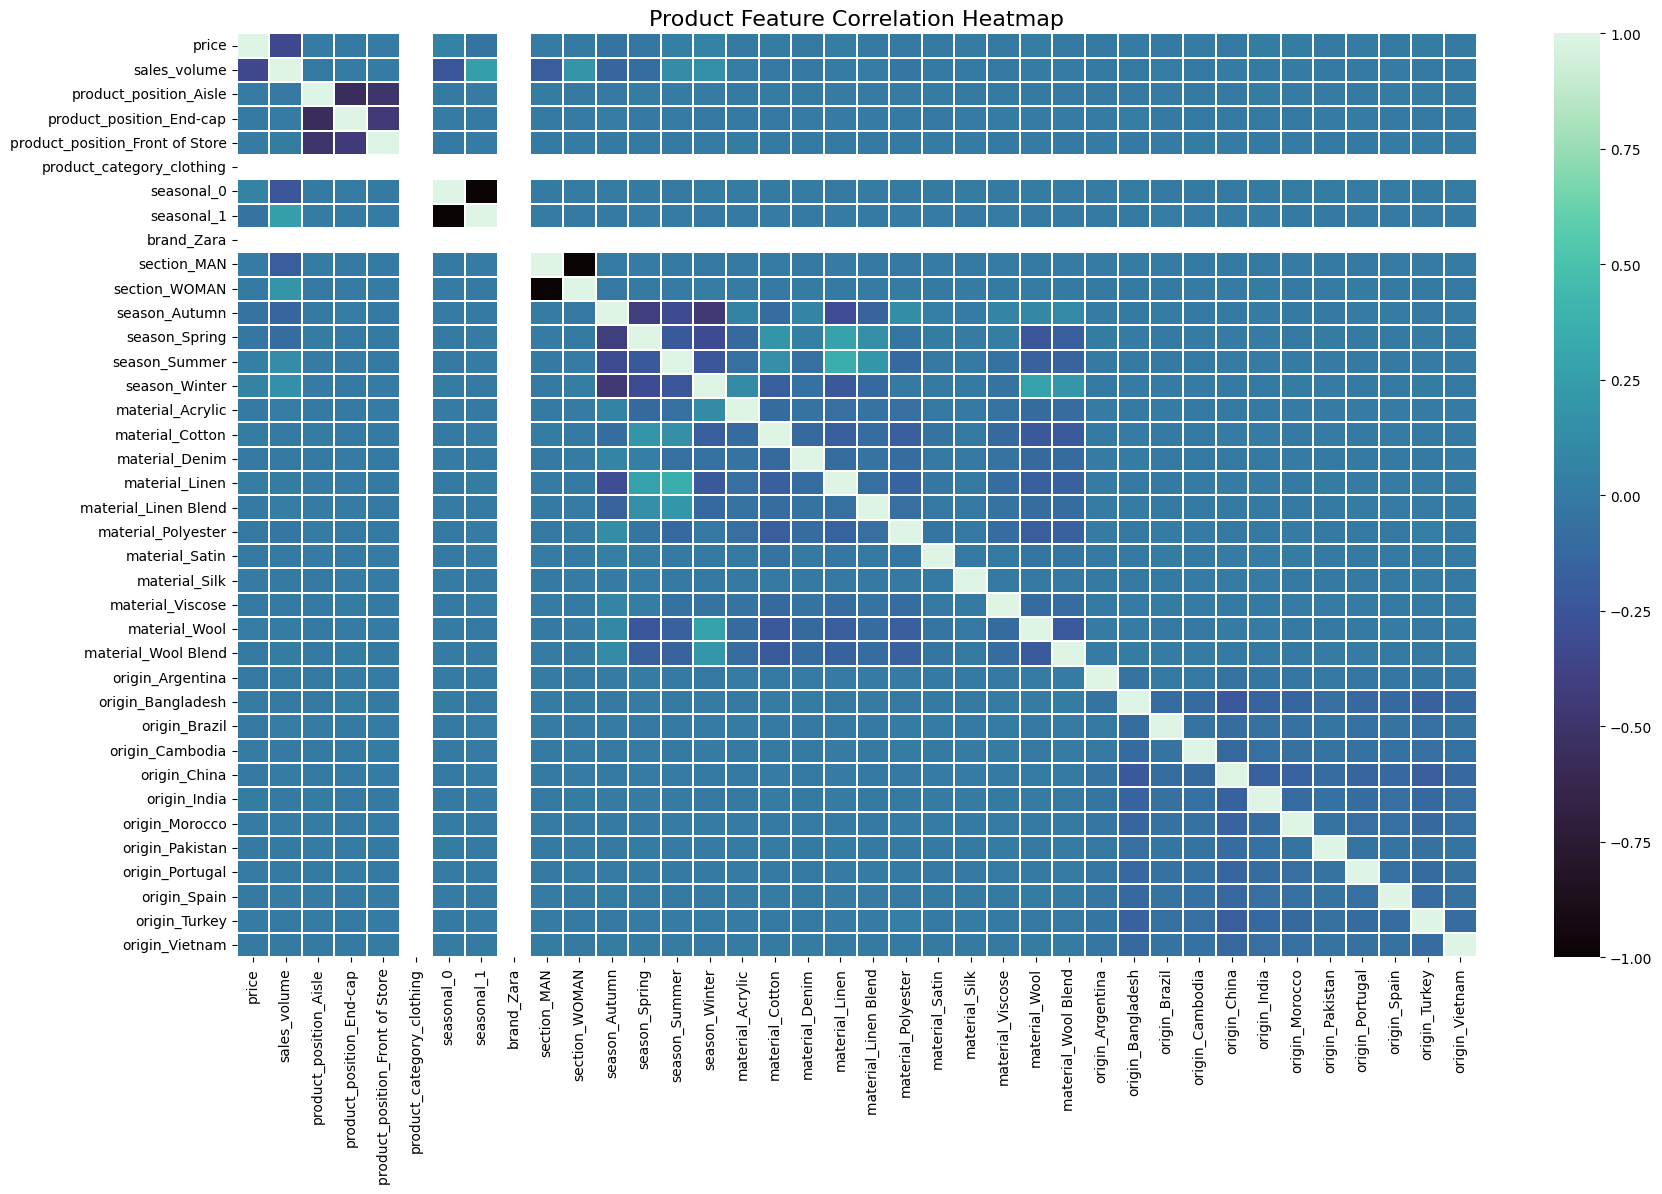

In [11]:
plt.figure(figsize=(20, 12))
sns.heatmap(combined.corr(), cmap="mako", linewidths=0.2)
plt.title("Product Feature Correlation Heatmap", fontsize=16)
plt.show()


### Price vs Sales Volume Heatmap
This heatmap reveals how different price ranges relate to total sales volumes.


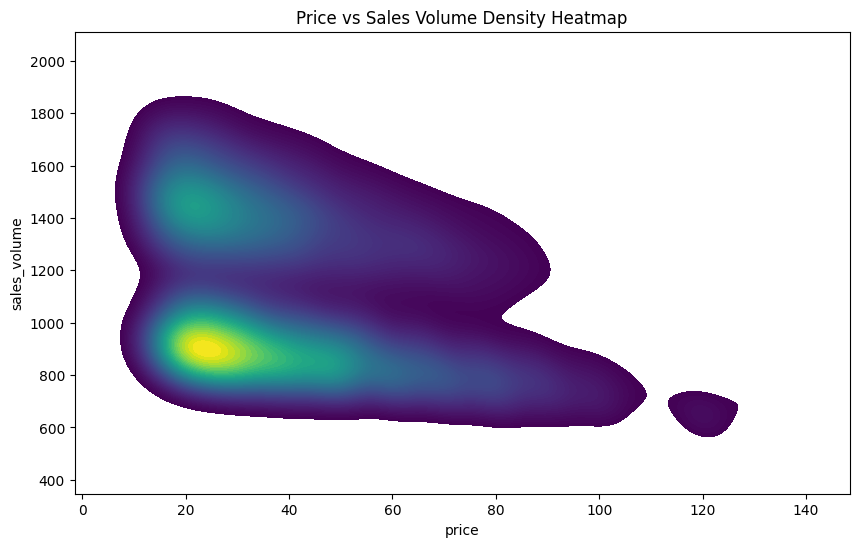

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=dataframe,
    x="price",
    y="sales_volume",
    fill=True,
    thresh=0.05,
    levels=80,
    cmap="viridis"
)
plt.title("Price vs Sales Volume Density Heatmap")
plt.show()


### Sales Distribution by Product Position


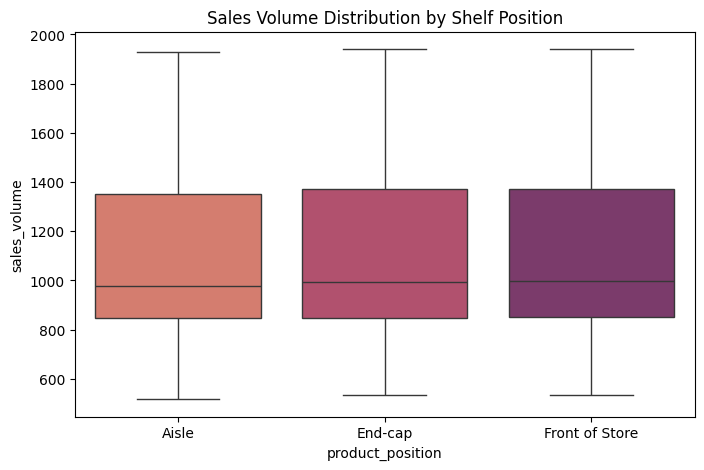

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=dataframe, x="product_position", y="sales_volume", palette="flare")
plt.title("Sales Volume Distribution by Shelf Position")
plt.show()


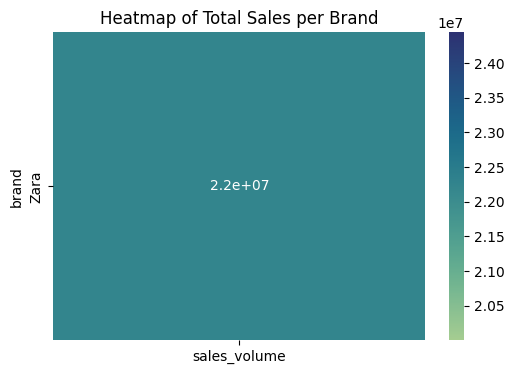

In [14]:
brand_sales = dataframe.groupby("brand")["sales_volume"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.heatmap(
    brand_sales.pivot_table(values="sales_volume", index="brand"),
    annot=True,
    cmap="crest"
)
plt.title("Heatmap of Total Sales per Brand")
plt.show()
